In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from Scripts import Outlier_detection_v2
from Scripts import Genes_self_similarity_v2
from matplotlib_venn import venn2, venn2_circles
from tqdm import tqdm
from Scripts_Imane import Format_Data

/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:6: DtypeWarning: Columns (0,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data_path = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-03-25.csv')


In [5]:
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1_mutants&WT_with_slopes.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')

/tmp/ipykernel_1647394/3503198913.py:2: DtypeWarning: Columns (463,464) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


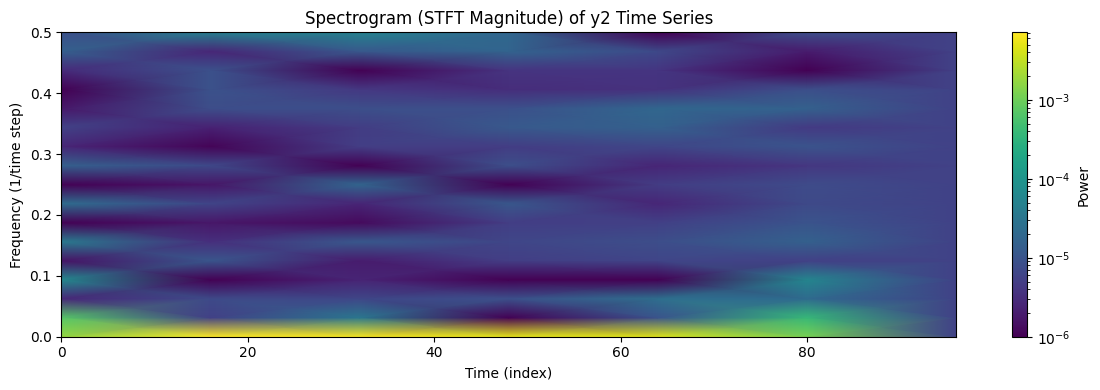

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from matplotlib.colors import LogNorm
data = old
# Define the time series columns
y2_cols = [col for col in data.columns if col.startswith('y2_') and 'std' not in col]

data = data[(data['light_regime']=='30s-30s') & (data['mutant_ID']!='WT') & (data['plate']==3)]
# Choose one row to visualize (e.g., the first mutant time series)
row = data.iloc[0][y2_cols].dropna().values.astype(float)

# Define a pseudo sampling rate (1 unit per time step)
fs = 1.0  

# Compute STFT
f, t, Zxx = stft(row, fs=fs, nperseg=32, noverlap=16, window='boxcar')  # adjust nperseg if needed

# Compute power spectrogram
spectrogram = np.abs(Zxx)**2

# Plot
plt.figure(figsize=(12, 4))
plt.pcolormesh(t, f, spectrogram, norm=LogNorm(vmin=1e-6, vmax=np.max(spectrogram)), shading='gouraud')
plt.title('Spectrogram (STFT Magnitude) of y2 Time Series')
plt.ylabel('Frequency (1/time step)')
plt.xlabel('Time (index)')
plt.colorbar(label='Power')
plt.tight_layout()
plt.show()


In [7]:
data = new


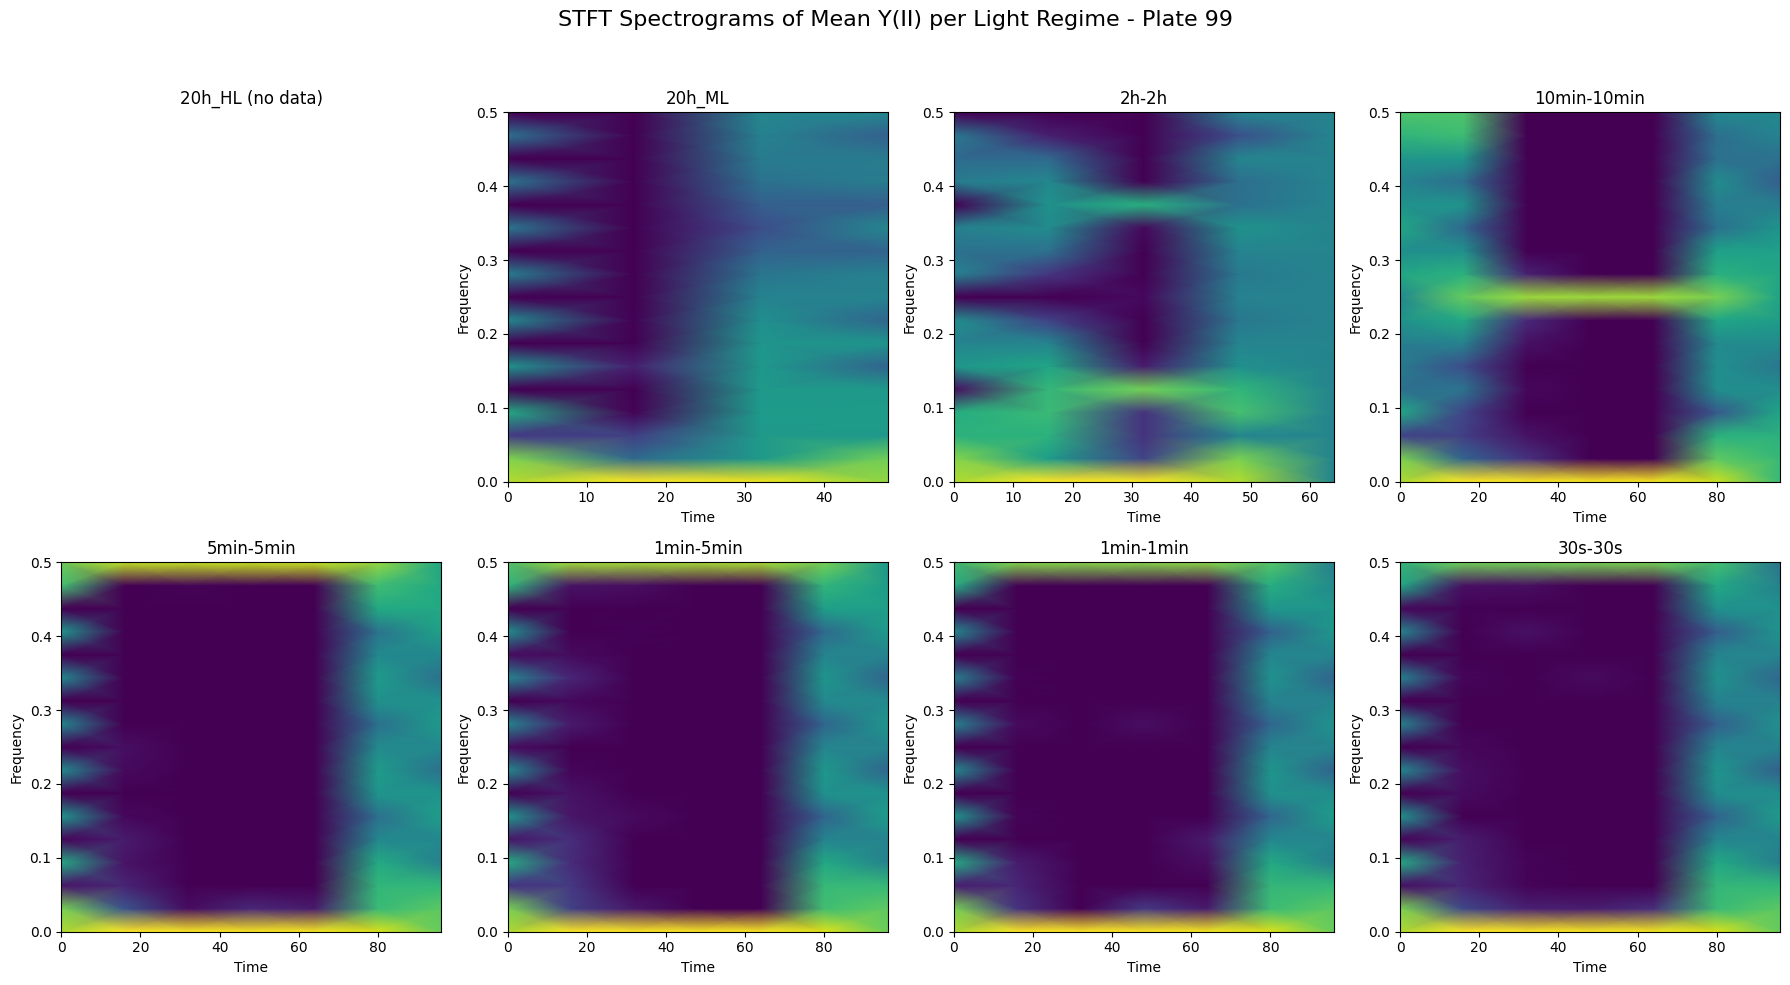

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft
from matplotlib.colors import LogNorm

# Define y2 columns
y2_cols = [col for col in data.columns if col.startswith('y2_') and 'std' not in col]

# Define light regimes and the plate of interest
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min','1min-5min', '1min-1min', '30s-30s']
plate_of_interest = 99  # or 99 if it's stored as int

# Sampling frequency (1 per time step unit)
fs = 1.0

# Grid setup
ncols = 4
nrows = int(np.ceil(len(light_regimes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))
axes = axes.flatten()
pcm = None  # Initialize to None

# Loop through light regimes
for i, regime in enumerate(light_regimes):
    ax = axes[i]
    
    # Filter data for this light regime and plate
    subset = data[(data['light_regime'] == regime) & (data['plate'].astype(str) == str(plate_of_interest))]
    
    # Compute mean y2 signal across replicates (rows)
    y2_matrix = subset[y2_cols].dropna(axis=1).astype(float).values
    if y2_matrix.shape[0] == 0:
        ax.set_title(f'{regime} (no data)')
        ax.axis('off')
        continue
    y2_mean = np.nanmean(y2_matrix, axis=0)
    
    # Compute STFT
    f, t_stft, Zxx = stft(y2_mean, fs=fs, nperseg=32, noverlap=16, window='boxcar')
    spectrogram = np.abs(Zxx)**2
    
    # Plot
    pcm_candidate = ax.pcolormesh(t_stft, f, spectrogram, norm=LogNorm(vmin=1e-6, vmax=np.max(spectrogram)), shading='gouraud')
    if pcm is None:
        pcm = pcm_candidate
    ax.set_title(regime)
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Time')

# Remove unused axes
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Add colorbar
#cbar = fig.colorbar(pcm, ax=axes.tolist(), shrink=0.95, label='Power')

plt.suptitle(f"STFT Spectrograms of Mean Y(II) per Light Regime - Plate {plate_of_interest}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [33]:
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
data = new
for light in light_regimes:
    data_light = data[data['light_regime']==light]
    print (light, len(data_light['mutant_ID'].unique()))

20h_HL 1175
20h_ML 1184
2h-2h 1185
10min-10min 1185
5min-5min 1201
1min-5min 1195
1min-1min 1192
30s-30s 1184


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def detect_and_plot_slope_outliers(data, alpha=0.05, plot=True):
    data_cluster = pd.DataFrame()

    for light in data['light_regime'].unique():
        data_light = data[data['light_regime'] == light].reset_index(drop=True)
        wt_slopes = data_light[(data_light['mutant_ID'] == 'WT') & (data_light['nullWT']==True)]['y2_slope'].dropna().values

        if len(wt_slopes) < 2:
            continue

        mu, sigma = norm.fit(wt_slopes)
        ci_low, ci_high = norm.interval(1 - alpha, loc=mu, scale=sigma)

        data_light['slope_cluster_y2'] = 0
        data_light['y2_deviation'] = 0.0

        for idx in data_light.index:
            slope = data_light.loc[idx, 'y2_slope']
            if not np.isfinite(slope):
                continue

            if slope < ci_low:
                data_light.loc[idx, 'slope_cluster_y2'] = -1
                data_light.loc[idx, 'y2_deviation'] = ci_low - slope
            elif slope > ci_high:
                data_light.loc[idx, 'slope_cluster_y2'] = 1
                data_light.loc[idx, 'y2_deviation'] = slope - ci_high
            else:
                data_light.loc[idx, 'y2_deviation'] = 0

        data_cluster = pd.concat([data_cluster, data_light])

        if plot:
            # Exclude WT and WT CLiP from plotting
            to_plot = data_light[~data_light['mutant_ID'].isin(['WT', 'WT CLiP'])].copy()

            color_map = {-1: 'blue', 0: 'lightgray', 1: 'red'}
            colors = to_plot['slope_cluster_y2'].map(color_map)

            #plt.figure(figsize=(10, 5))
            # plt.scatter(
            #     range(len(to_plot)), 
            #     to_plot['y2_slope'], 
            #     c=colors, 
            #     alpha=0.6, 
            #     edgecolors='k', 
            #     linewidths=0.3
            # )
            
            # plt.figure(figsize=(12, 5))
            # plt.scatter(
            #     range(len(to_plot)),
            #     to_plot['y2_slope'],
            #     c=to_plot['slope_cluster_y2'].map({-1: 'blue', 0: 'lightgray', 1: 'red'}),
            #     alpha=0.6,
            #     edgecolors='k',
            #     linewidths=0.3
            # )
            
            import seaborn as sns
            #Créer une palette de couleurs par plaque
            unique_plates = to_plot['plate'].unique()
            palette = dict(zip(unique_plates, sns.color_palette("husl", len(unique_plates))))
            plate_colors = to_plot['plate'].map(palette)

            # Dessin
            plt.figure(figsize=(12, 5))
            plt.scatter(
                range(len(to_plot)), 
                to_plot['y2_slope'], 
                c=plate_colors, 
                alpha=0.7,
                edgecolors='k',
                linewidths=0.3
            )

            # Lignes horizontales de référence
            plt.axhline(ci_low, color='gray', linestyle='--', label='CI lower bound')
            plt.axhline(ci_high, color='gray', linestyle='--', label='CI upper bound')
            plt.axhline(mu, color='black', linestyle='-', label='WT mean')

            # Afficher les noms de plaques sur l'axe X
            xtick_spacing = max(1, len(to_plot) // 20)
            xtick_positions = range(0, len(to_plot), xtick_spacing)
            xtick_labels = to_plot['plate'].values[::xtick_spacing]

            plt.xticks(ticks=xtick_positions, labels=xtick_labels, rotation=90)

            plt.ylabel('y2_slope')
            count_str = " | ".join([f"{k}: {to_plot['slope_cluster_y2'].tolist().count(k)}" for k in [-1, 0, 1]])
            plt.title(f'y2_slope — {light} — counts [{count_str}]')
            plt.xlabel('plate')
            plt.legend()
            plt.tight_layout()
            plt.show()
    return data_cluster


/tmp/ipykernel_1647394/1622693757.py:72: DtypeWarning: Columns (463,464) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


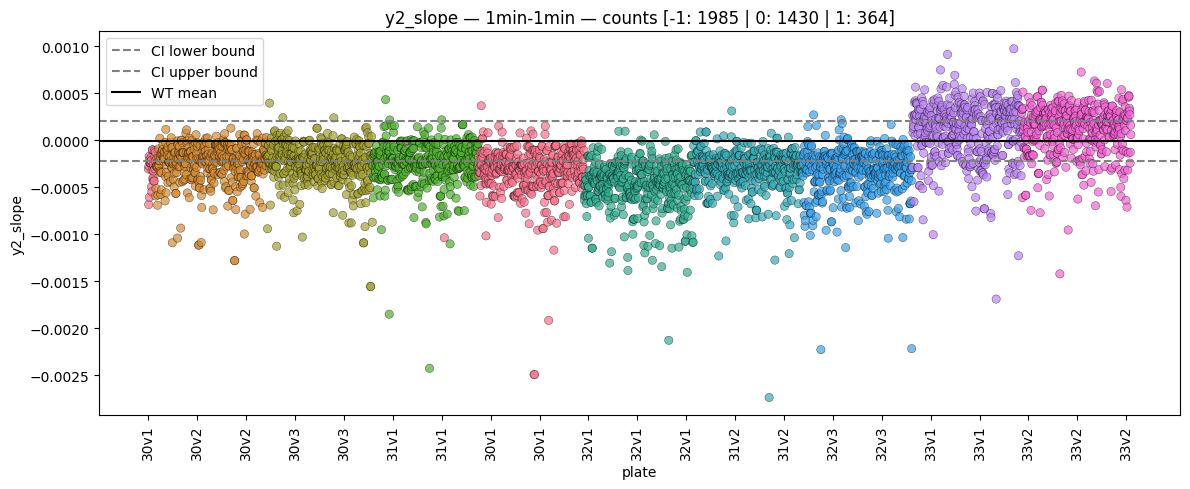

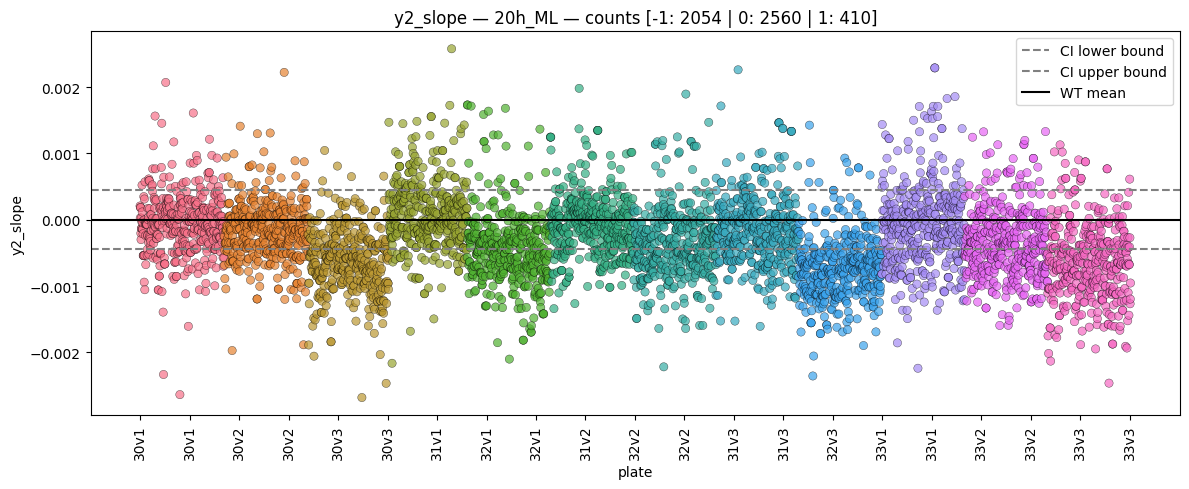

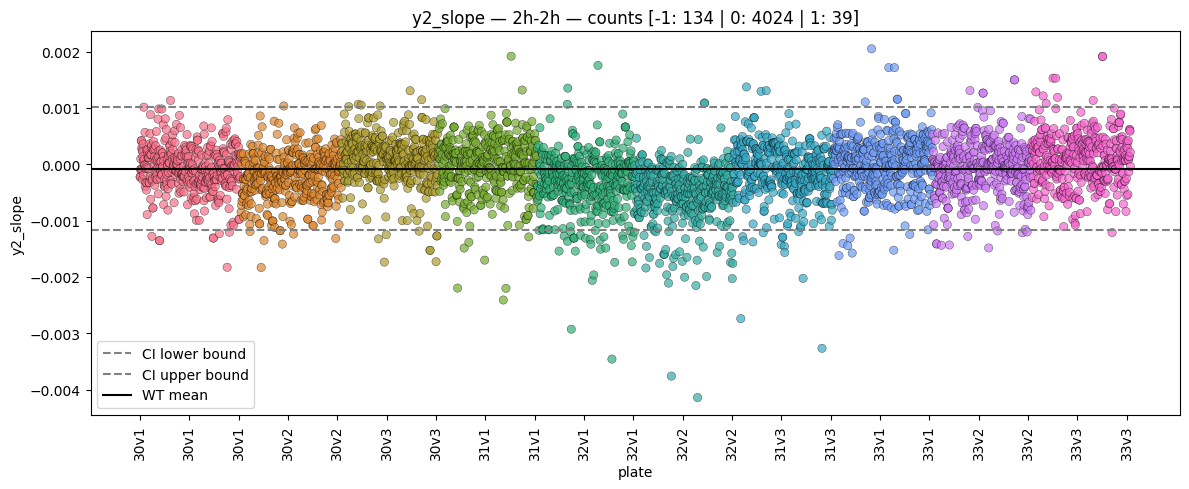

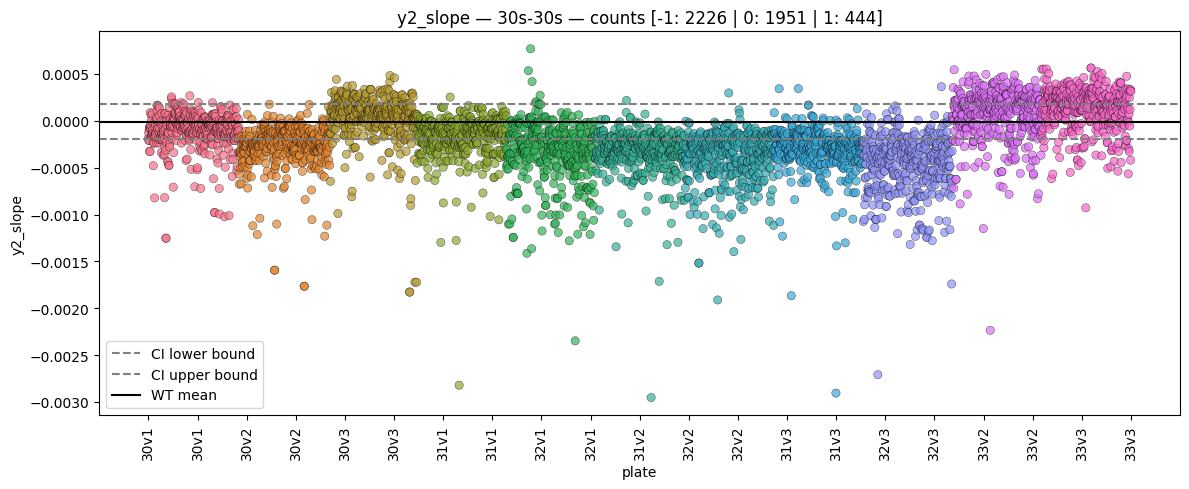

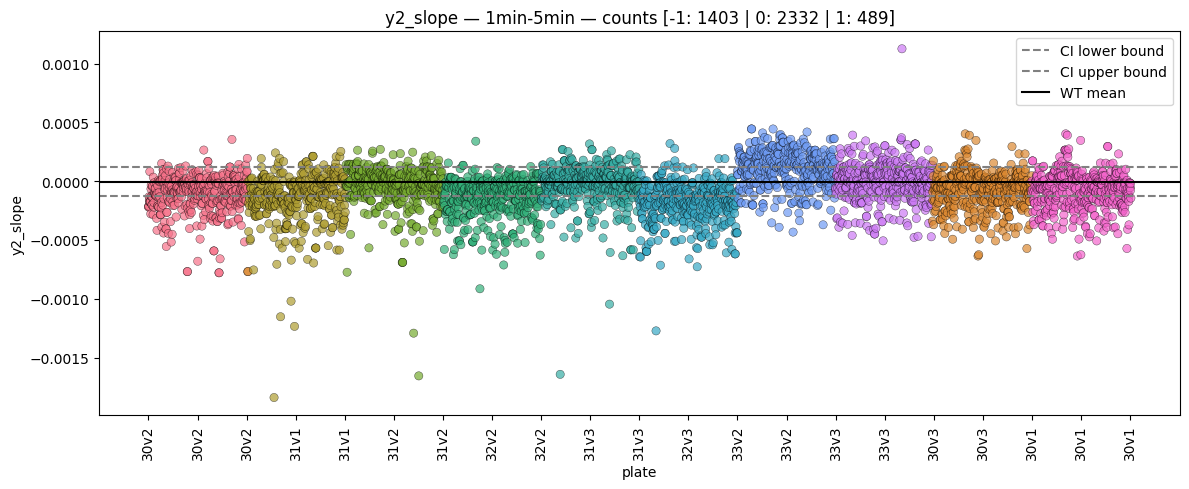

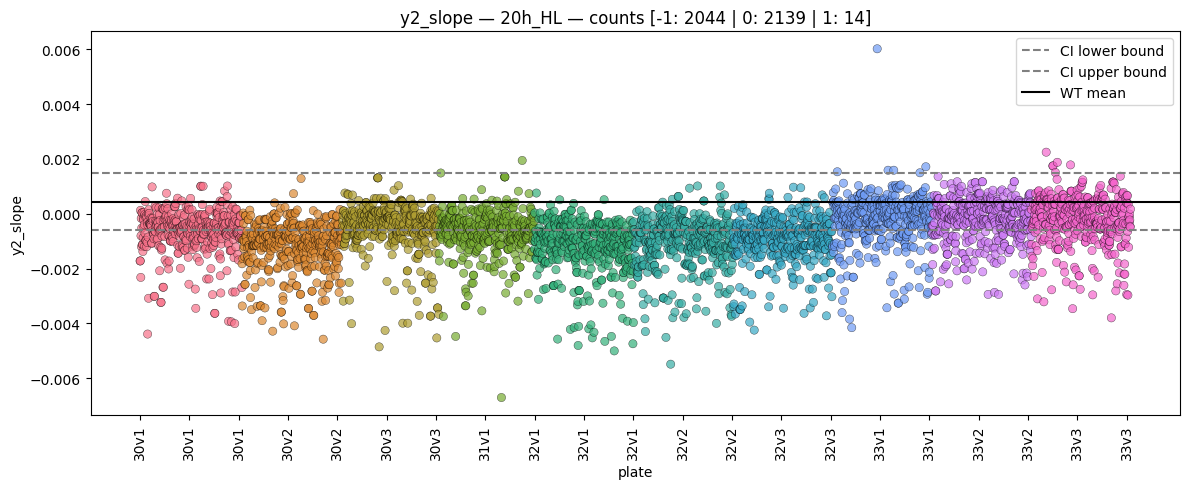

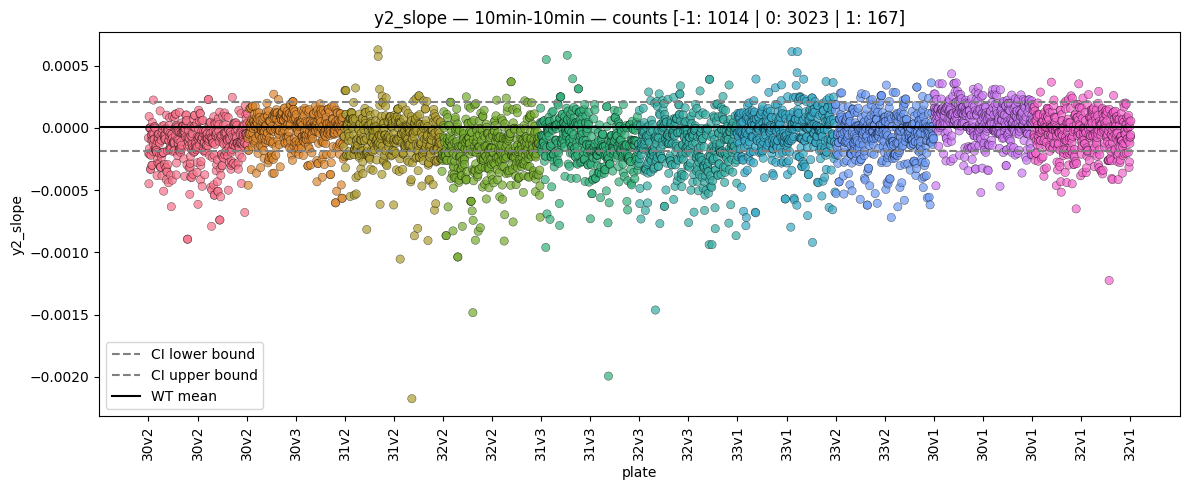

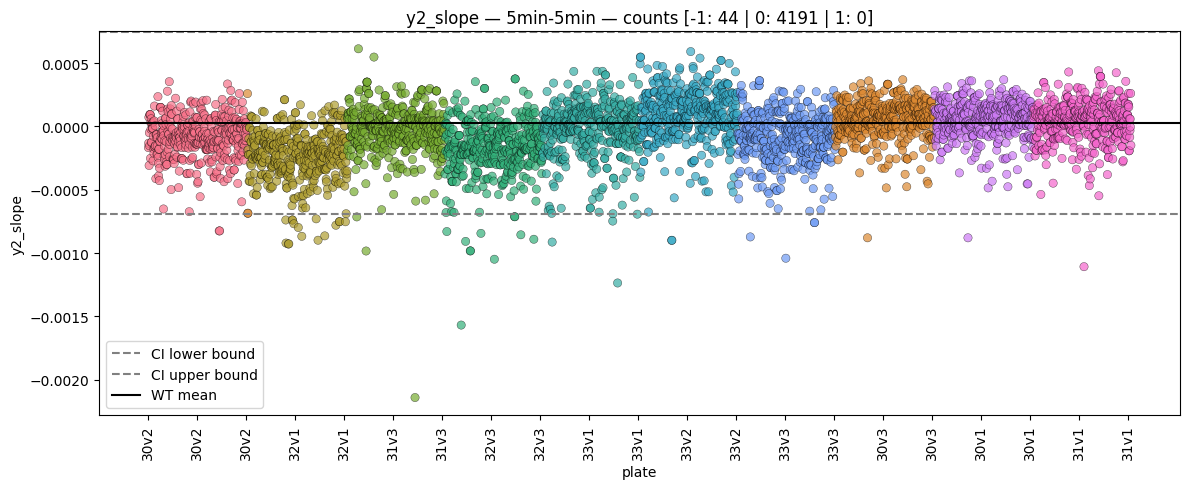

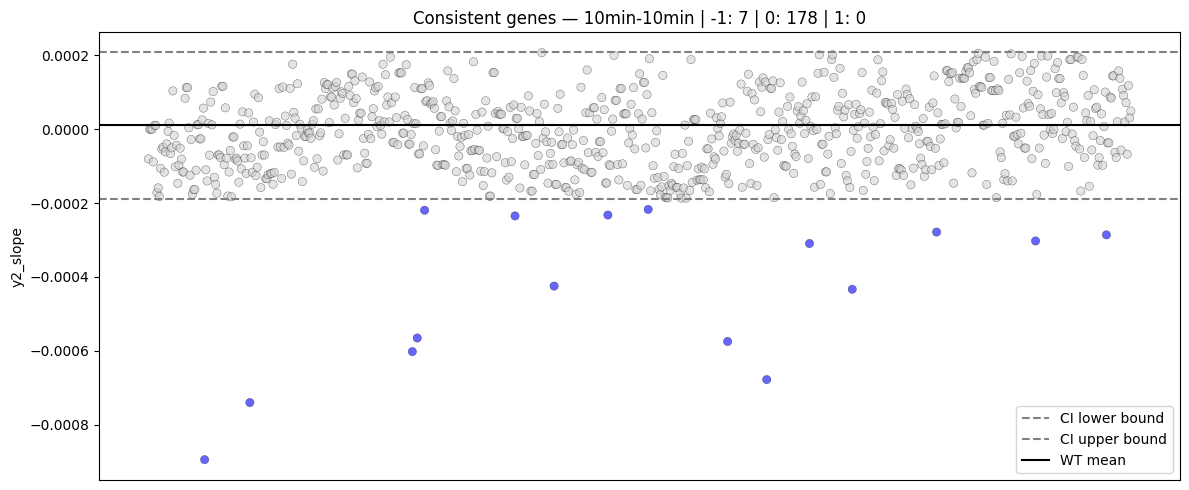

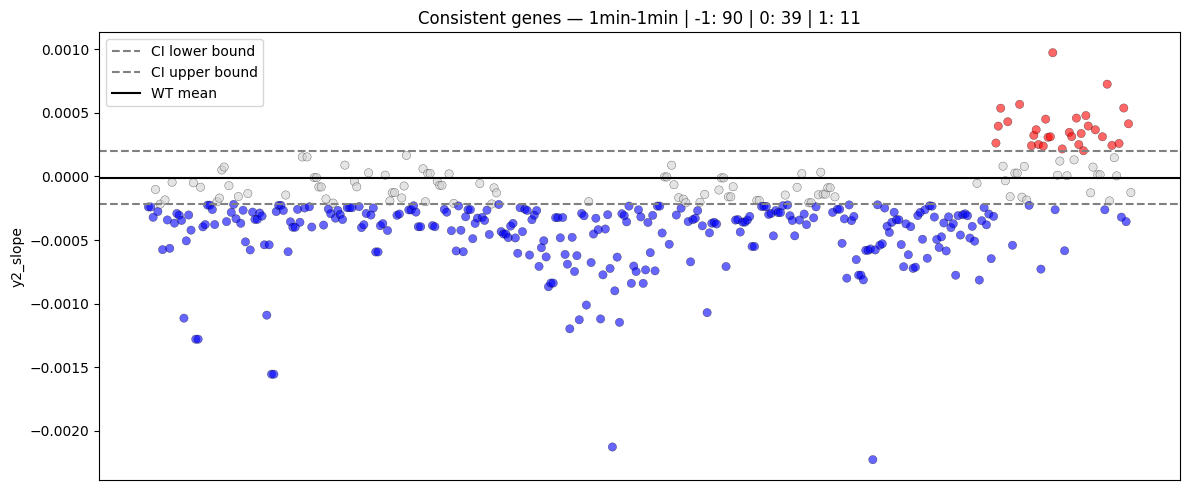

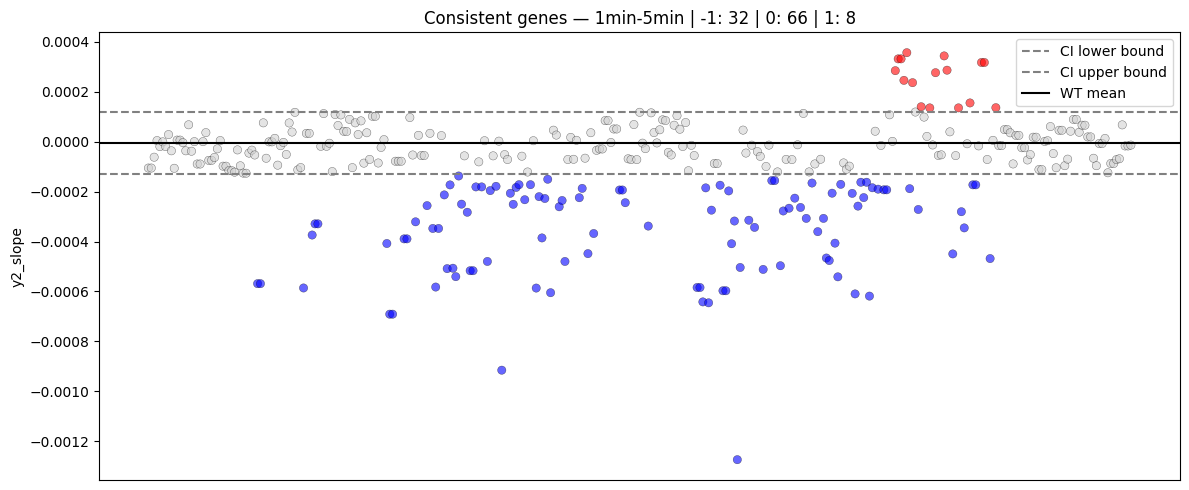

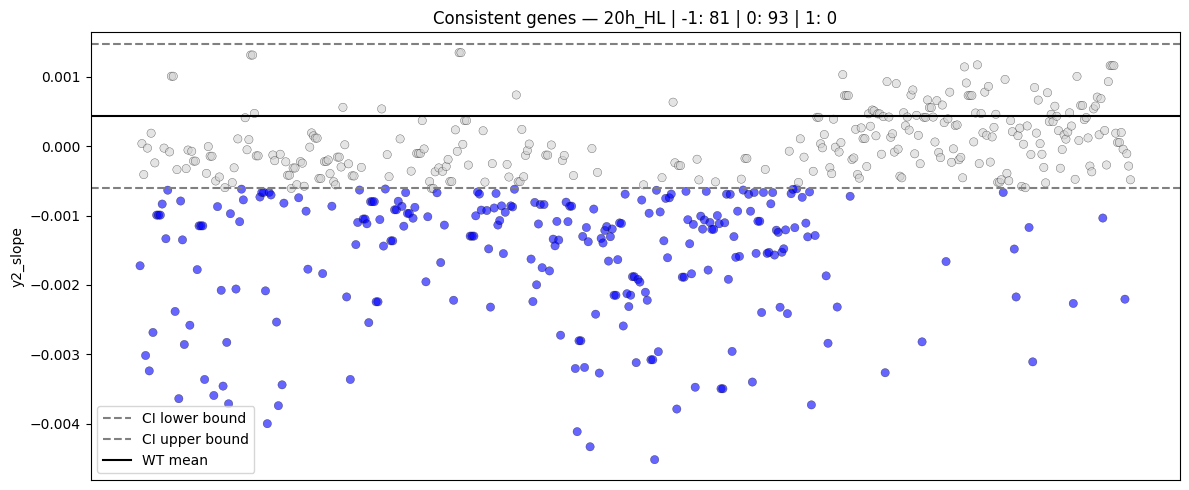

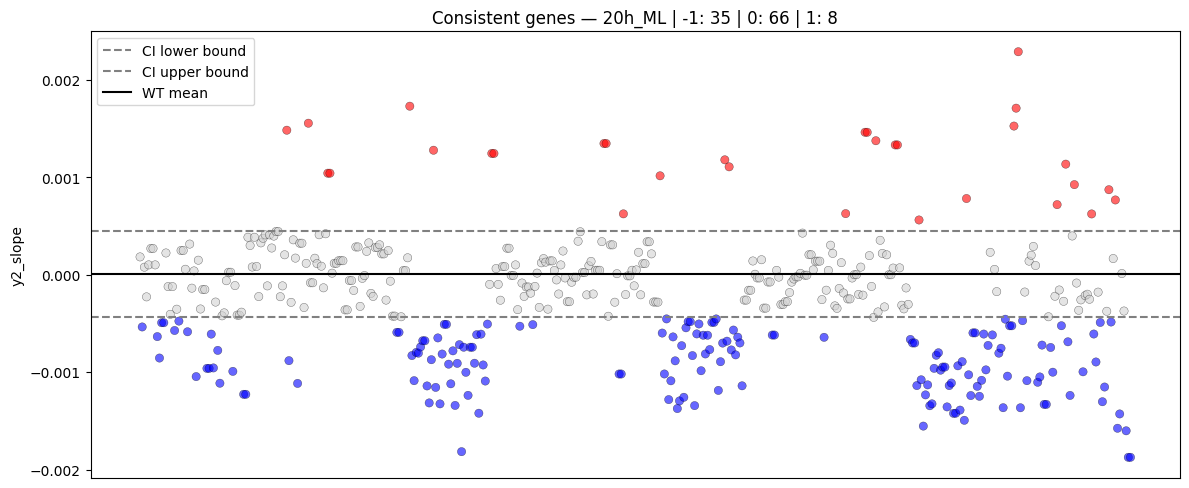

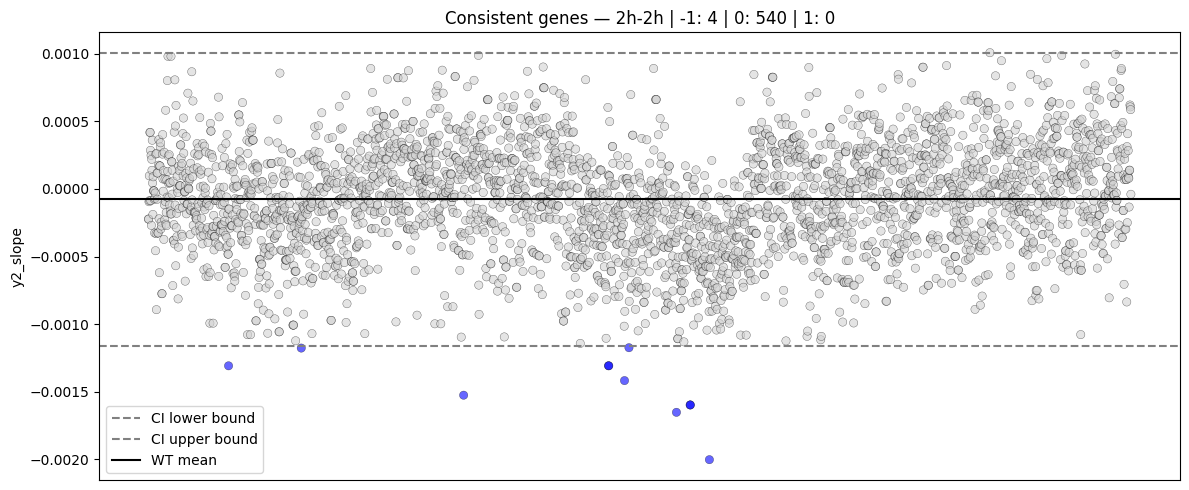

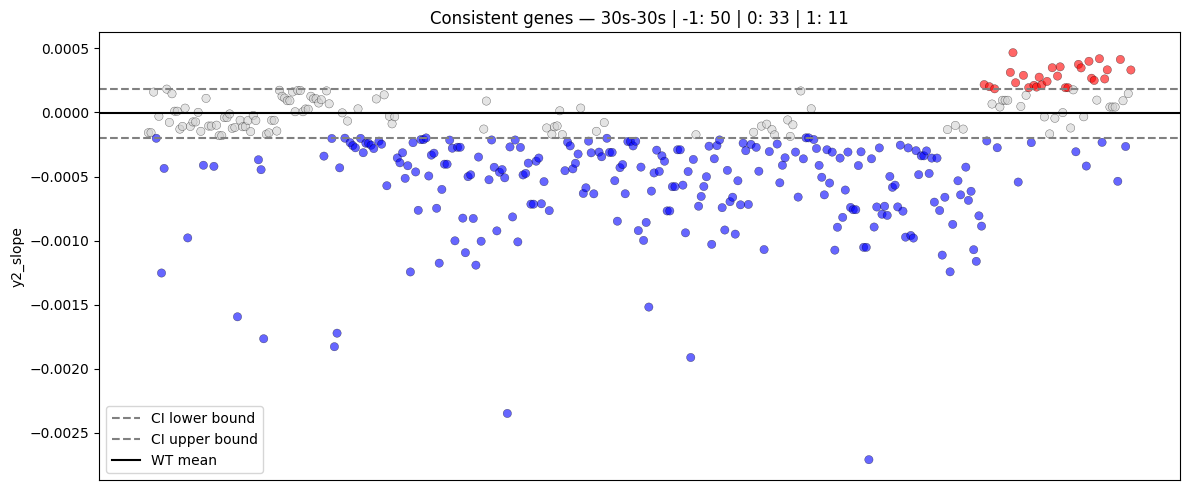

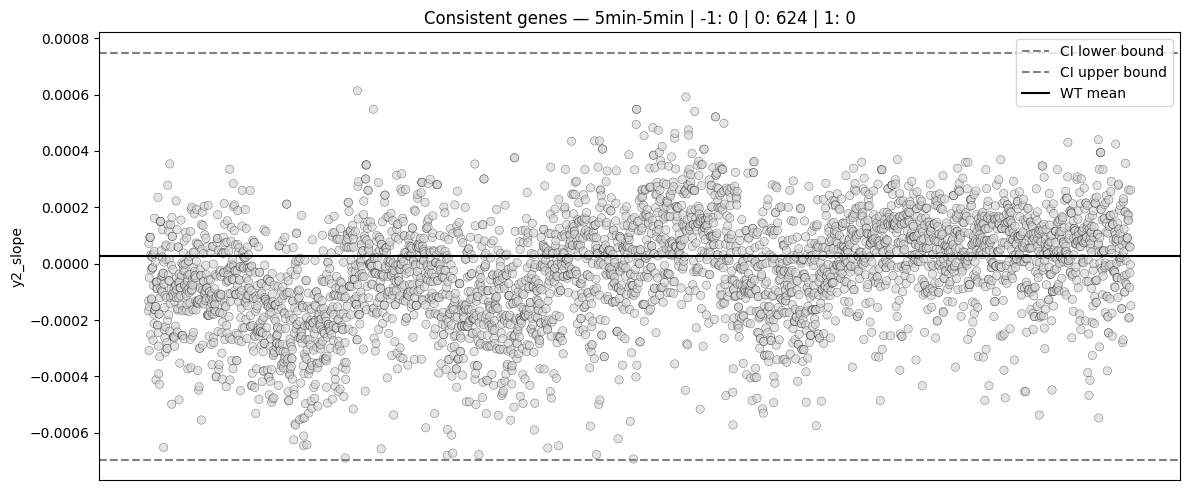

In [13]:
def plot_consistent_genes(data_cluster, plot=True):
    from collections import defaultdict
    from scipy.stats import norm
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    filtered = data_cluster[~data_cluster['mutant_ID'].isin(['WT', 'WT CLiP'])].copy()
    all_records = []

    for regime, group in filtered.groupby('light_regime'):
        for gene, subgrp in group.groupby('mutated_genes'):
            clusters = subgrp['slope_cluster_y2'].tolist()
            mutants = subgrp['mutant_ID'].tolist()
            all_records.append({
                'gene': gene,
                'clusters': clusters,
                'mutants': mutants,
                'light_regime': regime
            })

        if plot:
            # Filter consistent genes
            consistent_genes = [r['gene'] for r in all_records if r['light_regime'] == regime and len(set(r['clusters'])) == 1]
            consistent_data = group[group['mutated_genes'].isin(consistent_genes)].copy()

            # Plot
            color_map = {-1: 'blue', 0: 'lightgray', 1: 'red'}
            colors = consistent_data['slope_cluster_y2'].map(color_map)

            # WT stats
            wt_data = data_cluster[(data_cluster['light_regime'] == regime) &
                                   (data_cluster['mutant_ID'] == 'WT')]
            wt_slopes = wt_data['y2_slope'].dropna().values
            if len(wt_slopes) >= 2:
                mu, sigma = norm.fit(wt_slopes)
                ci_low, ci_high = norm.interval(0.95, loc=mu, scale=sigma)
            else:
                mu, ci_low, ci_high = np.nan, np.nan, np.nan

            # Compter les gènes cohérents par cluster
            consistent_clusters = consistent_data.groupby('mutated_genes')['slope_cluster_y2'].mean()
            counts = consistent_clusters.value_counts().to_dict()
            count_str = ' | '.join([f'{k}: {counts.get(k,0)}' for k in [-1, 0, 1]])

            plt.figure(figsize=(12, 5))
            plt.scatter(
                range(len(consistent_data)),
                consistent_data['y2_slope'],
                c=colors,
                alpha=0.6,
                edgecolors='k',
                linewidths=0.3
            )

            if np.isfinite(ci_low):
                plt.axhline(ci_low, color='gray', linestyle='--', label='CI lower bound')
                plt.axhline(ci_high, color='gray', linestyle='--', label='CI upper bound')
                plt.axhline(mu, color='black', linestyle='-', label='WT mean')

            plt.ylabel('y2_slope')
            plt.title(f'Consistent genes — {regime} | {count_str}')
            plt.xticks([], [])
            plt.legend()
            plt.tight_layout()
            plt.show()

    return pd.DataFrame(all_records)



data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')

result = detect_and_plot_slope_outliers(data, plot=True)
table = plot_consistent_genes(result)

In [24]:
table

,gene,clusters,mutants,light_regime
0,Cre01.g000100,"[0, 0]","[LMJ.RY0402.137230, LMJ.RY0402.220528]",10min-10min
1,Cre01.g000250,[0],[LMJ.RY0402.239650],10min-10min
2,Cre01.g000650,"[-1, 0]","[LMJ.RY0402.226866, LMJ.RY0402.066100]",10min-10min
3,Cre01.g001150,"[0, 0]","[LMJ.RY0402.233859, LMJ.RY0402.198780]",10min-10min
4,Cre01.g001200,[0],[LMJ.RY0402.192456],10min-10min
...,...,...,...,...
20521,Cre26.g756997,"[0, 0]","[LMJ.RY0402.106008, LMJ.RY0402.056125]",30s-30s
20522,Cre35.g759247,[0],[LMJ.RY0402.138955],30s-30s
20523,Cre36.g759697,"[0, 0]","[LMJ.RY0402.077951, LMJ.RY0402.129767]",30s-30s
20524,Cre49.g761297,[0],[LMJ.RY0402.203017],30s-30s


✅ Same cluster: 797
⚠️  Different cluster: 130
🟦 Only in dataset 1: 12900
🟥 Only in dataset 2: 1049


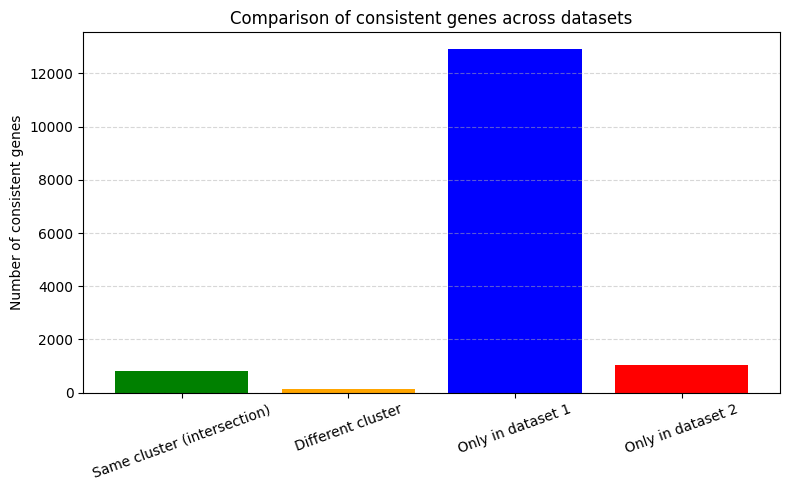

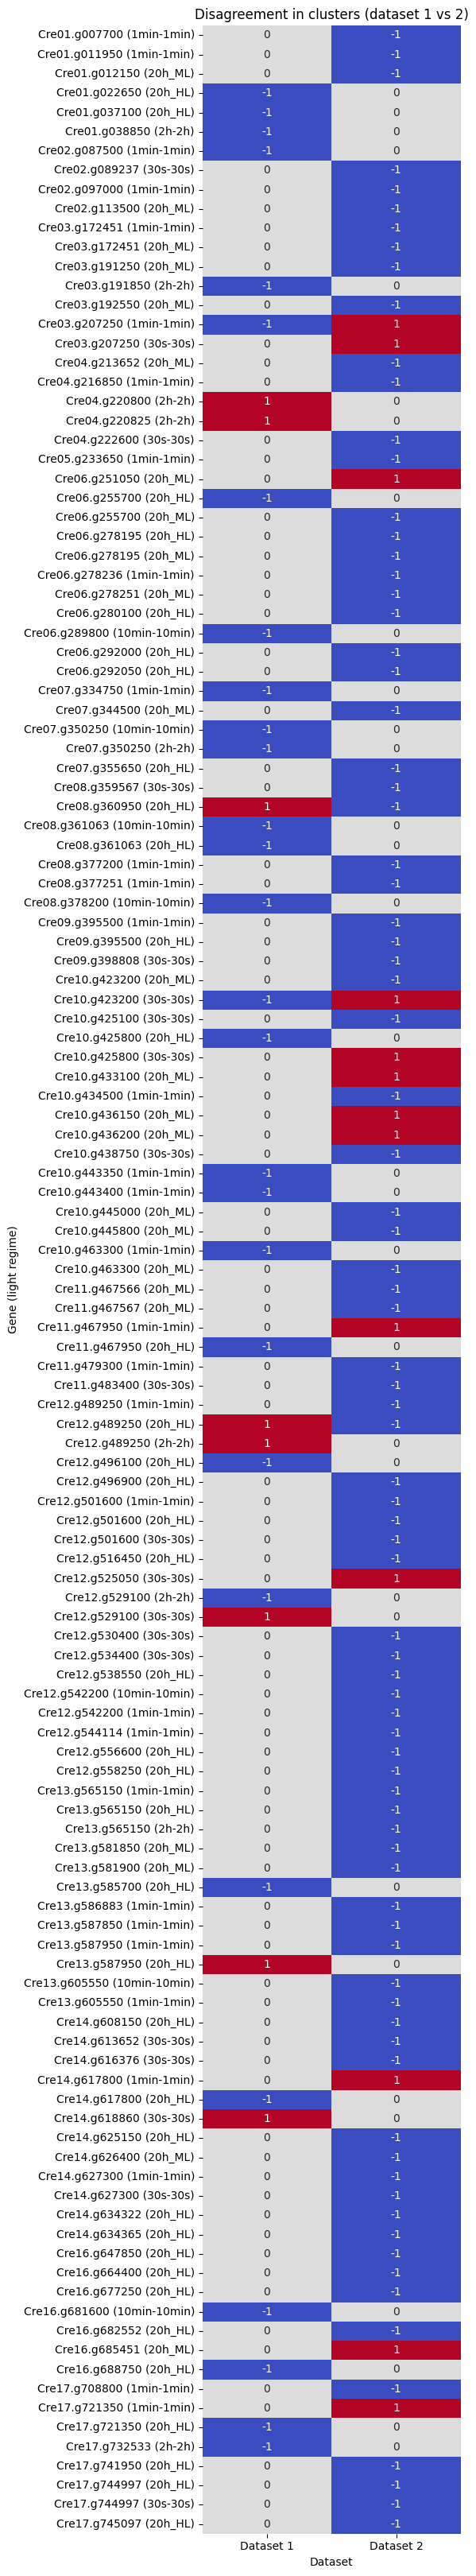

In [32]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# === Charger les données ===
table1 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase1_Gene_Clustering_per_mutants.csv')
table2 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase2_Gene_Clustering_per_mutants.csv')

# === Corriger le type des colonnes (listes) ===
for table in [table1, table2]:
    table['clusters'] = table['clusters'].apply(ast.literal_eval)
    table['mutants'] = table['mutants'].apply(ast.literal_eval)

# === Extraire les gènes cohérents ===
def get_consistent_genes(table):
    return table[table['clusters'].apply(lambda x: len(set(x)) == 1)].copy()

c1 = get_consistent_genes(table1)
c2 = get_consistent_genes(table2)

# Ajouter la valeur de cluster dominante
c1['cluster'] = c1['clusters'].apply(lambda x: x[0])
c2['cluster'] = c2['clusters'].apply(lambda x: x[0])

# Re-indexer sur (gene, light_regime)
c1_keyed = c1.set_index(['gene', 'light_regime'])[['cluster']]
c2_keyed = c2.set_index(['gene', 'light_regime'])[['cluster']]

# === Fusionner les deux jeux ===
merged = c1_keyed.join(c2_keyed, lsuffix='_1', rsuffix='_2', how='outer')
merged['match'] = merged['cluster_1'] == merged['cluster_2']

# === Catégoriser ===
common = merged.dropna()
agree = common[common['match']]
disagree = common[~common['match']]
only_in_1 = merged[merged['cluster_2'].isna()]
only_in_2 = merged[merged['cluster_1'].isna()]

# === Résumé texte ===
print(f"✅ Same cluster: {len(agree)}")
print(f"⚠️  Different cluster: {len(disagree)}")
print(f"🟦 Only in dataset 1: {len(only_in_1)}")
print(f"🟥 Only in dataset 2: {len(only_in_2)}")

# === Barplot résumé ===
counts = {
    'Same cluster (intersection)': len(agree),
    'Different cluster': len(disagree),
    'Only in dataset 1': len(only_in_1),
    'Only in dataset 2': len(only_in_2)
}

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color=['green', 'orange', 'blue', 'red'])
plt.ylabel("Number of consistent genes")
plt.title("Comparison of consistent genes across datasets")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Optionnel : heatmap des désaccords ===
if not disagree.empty:
    plt.figure(figsize=(6, max(3, len(disagree)*0.25)))
    sns.heatmap(
        disagree.reset_index()[['cluster_1', 'cluster_2']],
        annot=True, cmap='coolwarm', cbar=False,
        yticklabels=disagree.index.map(lambda x: f'{x[0]} ({x[1]})')
    )
    plt.title("Disagreement in clusters (dataset 1 vs 2)")
    plt.xlabel("Dataset")
    plt.xticks([0.5, 1.5], ["Dataset 1", "Dataset 2"])
    plt.ylabel("Gene (light regime)")
    plt.tight_layout()
    plt.show()


✅ Same cluster: 797
⚠️  Different cluster: 130
🟦 Only in dataset 1: 12900
🟥 Only in dataset 2: 1049


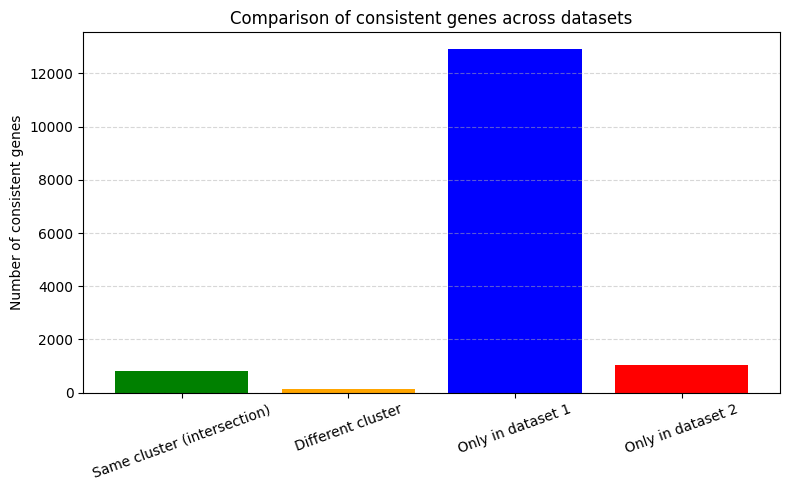

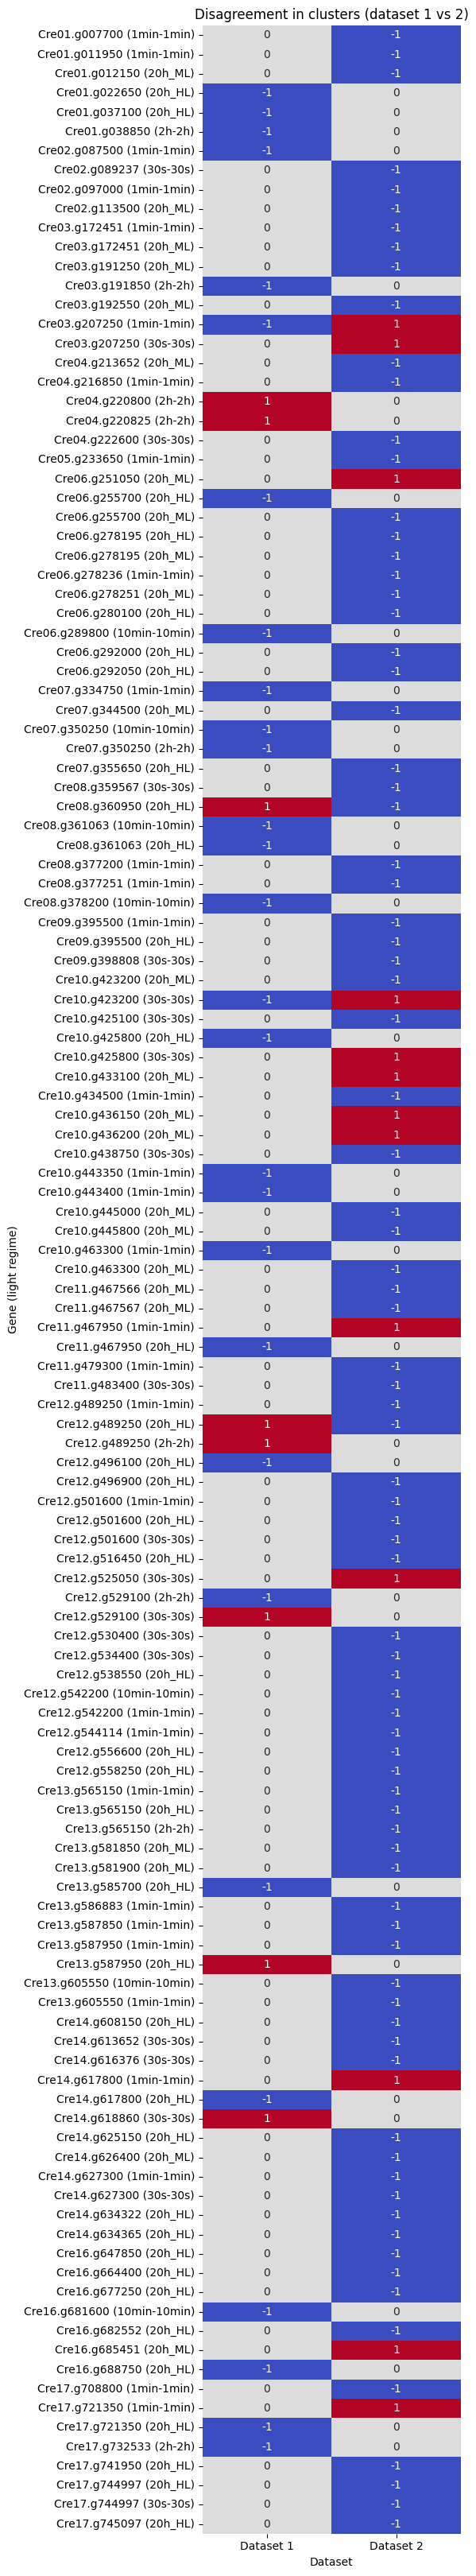

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# === Charger les données ===
table1 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase1_Gene_Clustering_per_mutants.csv')
table2 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase2_Gene_Clustering_per_mutants.csv')

# === Corriger le type des colonnes (listes) ===
for table in [table1, table2]:
    table['clusters'] = table['clusters'].apply(ast.literal_eval)
    table['mutants'] = table['mutants'].apply(ast.literal_eval)

# === Extraire les gènes cohérents ===
def get_consistent_genes(table):
    return table[table['clusters'].apply(lambda x: len(set(x)) == 1)].copy()

c1 = get_consistent_genes(table1)
c2 = get_consistent_genes(table2)

# Ajouter la valeur de cluster dominante
c1['cluster'] = c1['clusters'].apply(lambda x: x[0])
c2['cluster'] = c2['clusters'].apply(lambda x: x[0])

# Re-indexer sur (gene, light_regime)
c1_keyed = c1.set_index(['gene', 'light_regime'])[['cluster']]
c2_keyed = c2.set_index(['gene', 'light_regime'])[['cluster']]

# === Fusionner les deux jeux ===
merged = c1_keyed.join(c2_keyed, lsuffix='_1', rsuffix='_2', how='outer')
merged['match'] = merged['cluster_1'] == merged['cluster_2']

# === Catégoriser ===
common = merged.dropna()
agree = common[common['match']]
disagree = common[~common['match']]
only_in_1 = merged[merged['cluster_2'].isna()]
only_in_2 = merged[merged['cluster_1'].isna()]

# === Résumé texte ===
print(f"✅ Same cluster: {len(agree)}")
print(f"⚠️  Different cluster: {len(disagree)}")
print(f"🟦 Only in dataset 1: {len(only_in_1)}")
print(f"🟥 Only in dataset 2: {len(only_in_2)}")

# === Barplot résumé ===
counts = {
    'Same cluster (intersection)': len(agree),
    'Different cluster': len(disagree),
    'Only in dataset 1': len(only_in_1),
    'Only in dataset 2': len(only_in_2)
}

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color=['green', 'orange', 'blue', 'red'])
plt.ylabel("Number of consistent genes")
plt.title("Comparison of consistent genes across datasets")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Optionnel : heatmap des désaccords ===
if not disagree.empty:
    plt.figure(figsize=(6, max(3, len(disagree)*0.25)))
    sns.heatmap(
        disagree.reset_index()[['cluster_1', 'cluster_2']],
        annot=True, cmap='coolwarm', cbar=False,
        yticklabels=disagree.index.map(lambda x: f'{x[0]} ({x[1]})')
    )
    plt.title("Disagreement in clusters (dataset 1 vs 2)")
    plt.xlabel("Dataset")
    plt.xticks([0.5, 1.5], ["Dataset 1", "Dataset 2"])
    plt.ylabel("Gene (light regime)")
    plt.tight_layout()
    plt.show()


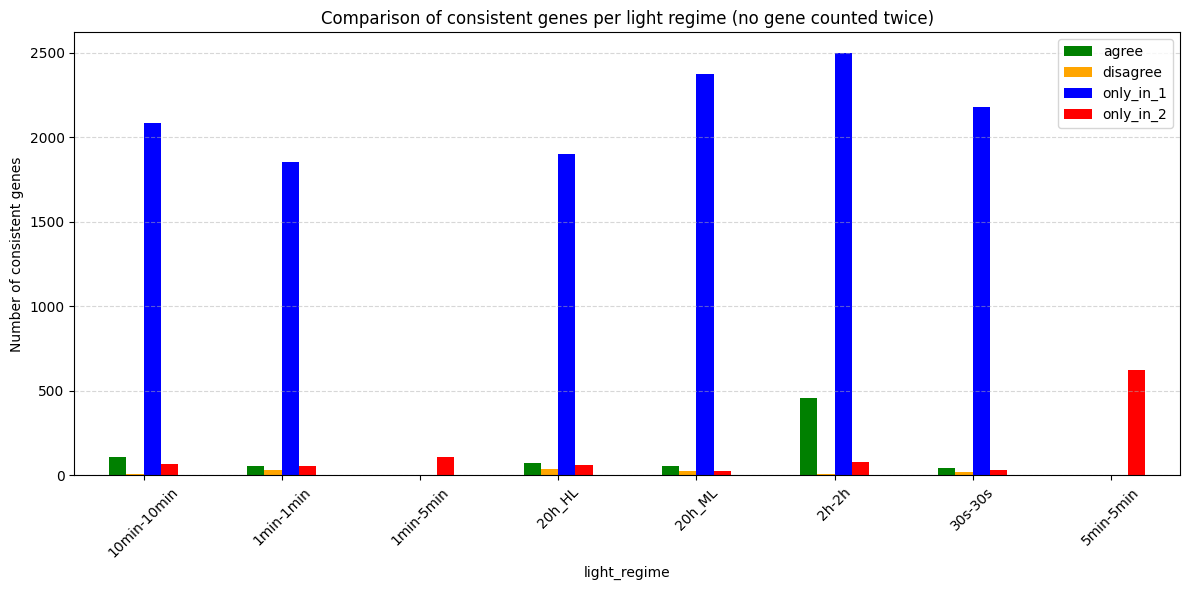

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Charger tes deux tables
table1 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase1_Gene_Clustering_per_mutants.csv')
table2 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase2_Gene_Clustering_per_mutants.csv')

# Convertir les listes encodées en string
for t in [table1, table2]:
    t['clusters'] = t['clusters'].apply(ast.literal_eval)
    t['mutants'] = t['mutants'].apply(ast.literal_eval)

# Gènes cohérents uniquement
def get_consistent_genes(table):
    table = table[table['clusters'].apply(lambda x: len(set(x)) == 1)].copy()
    table['cluster'] = table['clusters'].apply(lambda x: x[0])
    return table

c1 = get_consistent_genes(table1)
c2 = get_consistent_genes(table2)

# Identifier les régimes lumineux présents
regimes = sorted(set(c1['light_regime']) | set(c2['light_regime']))

# Créer un tableau résumé
summary = []
for regime in regimes:
    g1 = set(c1[c1['light_regime'] == regime]['gene'])
    g2 = set(c2[c2['light_regime'] == regime]['gene'])

    both = g1 & g2
    only1 = g1 - g2
    only2 = g2 - g1

    # Pour les gènes en commun, vérifier si le cluster est le même
    c1_clusters = c1.set_index(['gene', 'light_regime'])['cluster']
    c2_clusters = c2.set_index(['gene', 'light_regime'])['cluster']

    agree = 0
    disagree = 0
    for gene in both:
        try:
            if c1_clusters[(gene, regime)] == c2_clusters[(gene, regime)]:
                agree += 1
            else:
                disagree += 1
        except KeyError:
            pass  # mismatch index, skip

    summary.append({
        'light_regime': regime,
        'agree': agree,
        'disagree': disagree,
        'only_in_1': len(only1),
        'only_in_2': len(only2)
    })

# Dataframe pour visualisation
df = pd.DataFrame(summary)
df.set_index('light_regime', inplace=True)

# Bar plot groupé
df[['agree', 'disagree', 'only_in_1', 'only_in_2']].plot(
    kind='bar', figsize=(12, 6), color=['green', 'orange', 'blue', 'red']
)

plt.ylabel("Number of consistent genes")
plt.title("Comparison of consistent genes per light regime (no gene counted twice)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


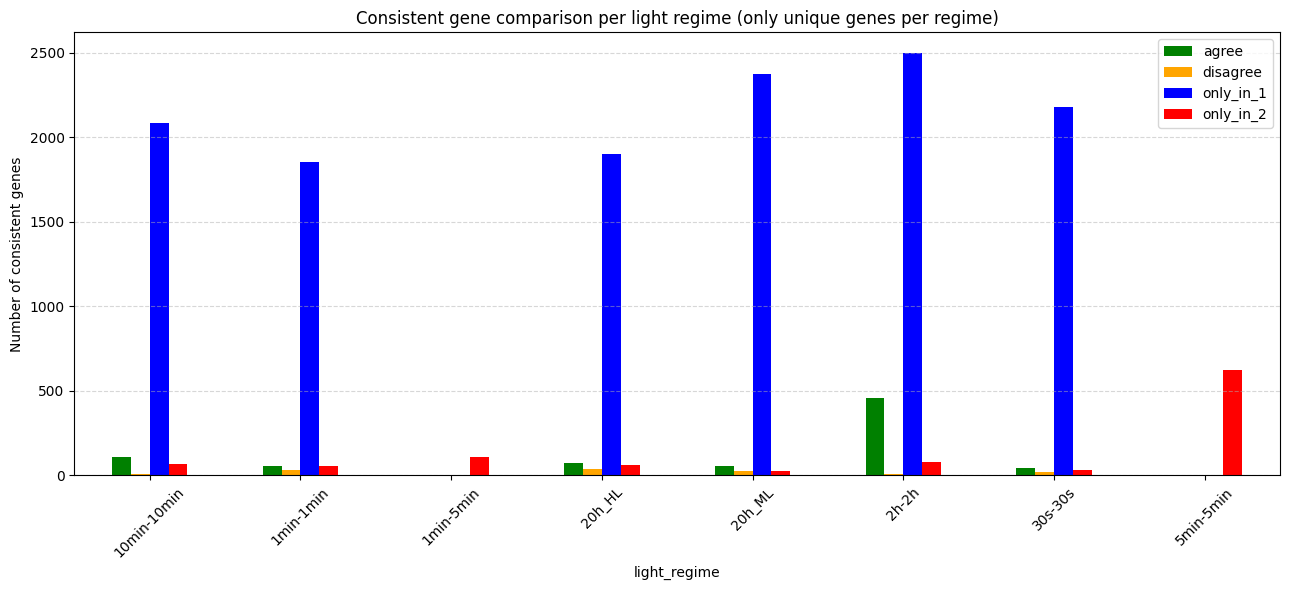

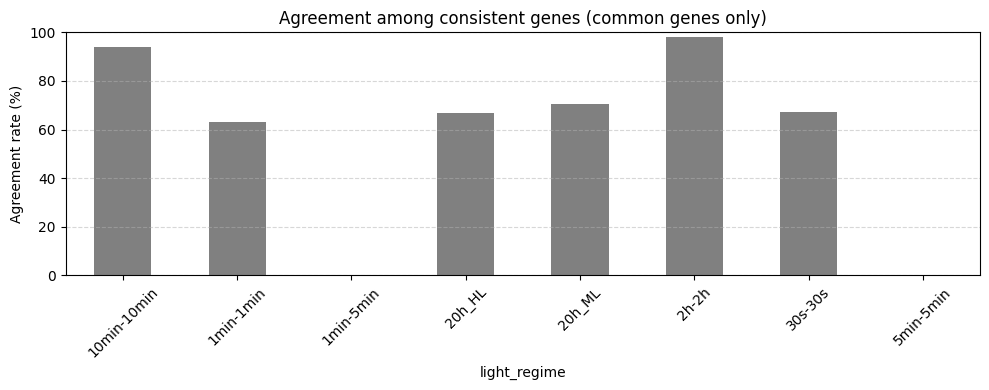

In [40]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Charger tes deux tables
# Charger tes deux tables
table1 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase1_Gene_Clustering_per_mutants.csv')
table2 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Phase2_Gene_Clustering_per_mutants.csv')

# Convertir les listes encodées en string
for t in [table1, table2]:
    t['clusters'] = t['clusters'].apply(ast.literal_eval)
    t['mutants'] = t['mutants'].apply(ast.literal_eval)

# Gènes cohérents uniquement
def get_consistent_genes(table):
    table = table[table['clusters'].apply(lambda x: len(set(x)) == 1)].copy()
    table['cluster'] = table['clusters'].apply(lambda x: x[0])
    return table

c1 = get_consistent_genes(table1)
c2 = get_consistent_genes(table2)

# Identifier les régimes lumineux présents
regimes = sorted(set(c1['light_regime']) | set(c2['light_regime']))

# Créer un tableau résumé
summary = []
for regime in regimes:
    g1 = set(c1[c1['light_regime'] == regime]['gene'])
    g2 = set(c2[c2['light_regime'] == regime]['gene'])

    both = g1 & g2
    only1 = g1 - g2
    only2 = g2 - g1

    # Pour les gènes en commun, vérifier si le cluster est le même
    c1_clusters = c1.set_index(['gene', 'light_regime'])['cluster']
    c2_clusters = c2.set_index(['gene', 'light_regime'])['cluster']

    agree = 0
    disagree = 0
    for gene in both:
        try:
            if c1_clusters[(gene, regime)] == c2_clusters[(gene, regime)]:
                agree += 1
            else:
                disagree += 1
        except KeyError:
            continue

    total_common = agree + disagree
    percent_agree = (agree / total_common * 100) if total_common > 0 else 0

    summary.append({
        'light_regime': regime,
        'agree': agree,
        'disagree': disagree,
        'only_in_1': len(only1),
        'only_in_2': len(only2),
        'total_common': total_common,
        'percent_agree': round(percent_agree, 1)
    })

# Résumé global par régime lumineux
df = pd.DataFrame(summary)
df.set_index('light_regime', inplace=True)

# Bar plot groupé
df[['agree', 'disagree', 'only_in_1', 'only_in_2']].plot(
    kind='bar', figsize=(13, 6), color=['green', 'orange', 'blue', 'red']
)
plt.ylabel("Number of consistent genes")
plt.title("Consistent gene comparison per light regime (only unique genes per regime)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot % d'accord uniquement sur les gènes communs
df['percent_agree'].plot(kind='bar', color='gray', figsize=(10, 4))
plt.ylabel("Agreement rate (%)")
plt.title("Agreement among consistent genes (common genes only)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
